### Lucas Kanade Optical Flow

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
cap = cv2.VideoCapture("data/videos/cycle.mp4")

In [3]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('sparse_output.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width, height))

In [5]:
# params for ShiTomasi corner detection
numCorners = 100
feature_params = dict(maxCorners = numCorners, qualityLevel = 0.3, minDistance = 7, blockSize = 7)

In [6]:
# Parameters for lucas kanade optical flow
lk_params = dict(winSize = (15, 15), maxLevel = 2, 
                 criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

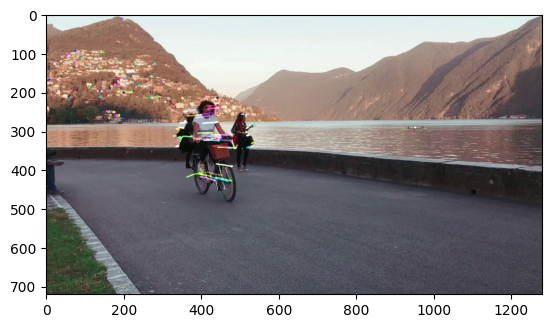

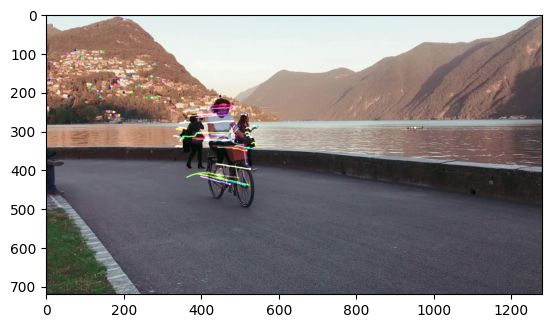

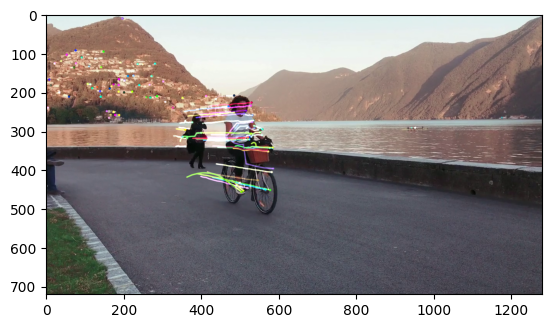

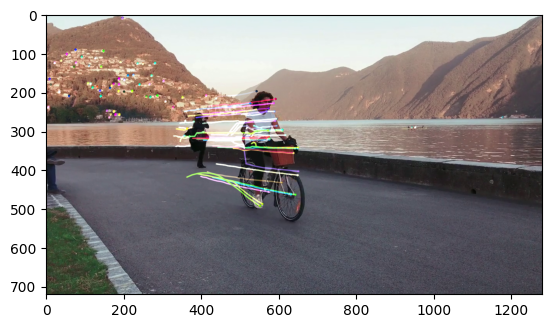

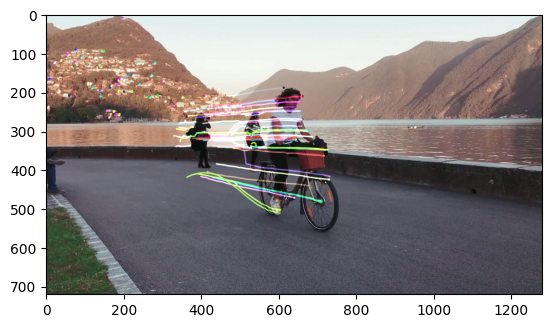

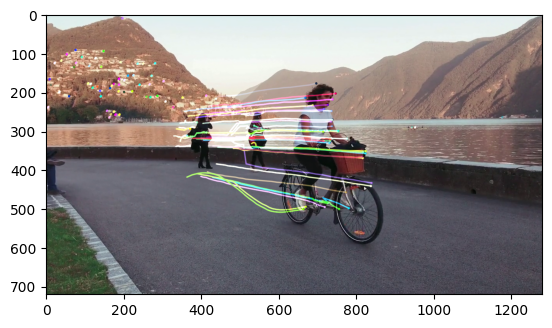

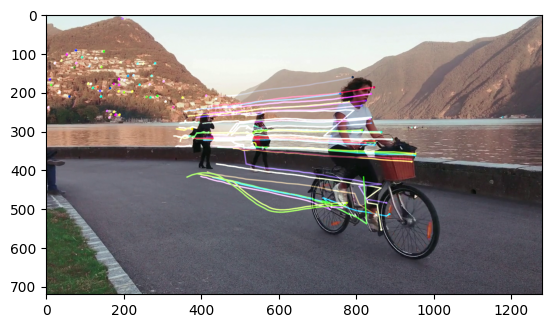

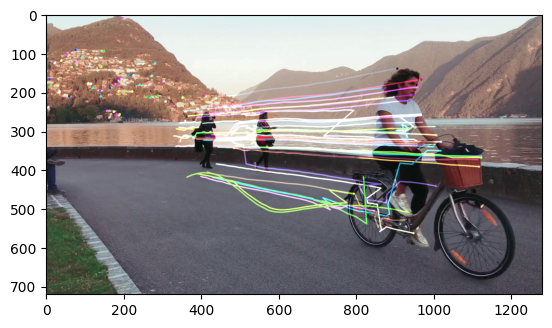

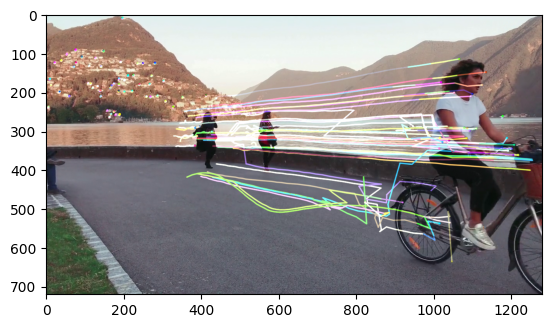

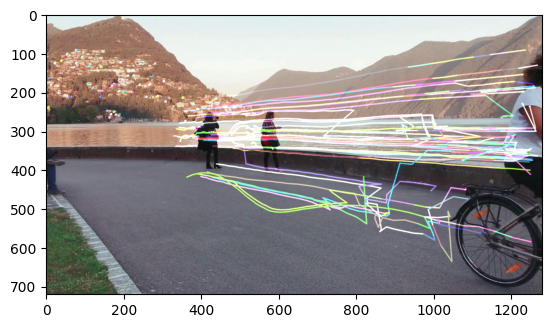

In [7]:
color = np.random.randint(0, 255, (numCorners, 3))

ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
old_points = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

mask = np.zeros_like(old_frame)
count = 0

while(1):
    ret, frame = cap.read()
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    count += 1

    # calculate new optical flow
    new_points, status, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, old_points, None, **lk_params)

    # Select good points
    good_new = new_points[status == 1]
    good_old = old_points[status == 1]

    # draw the tracks
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        cv2.line(img = mask, pt1 = (int(a), int(b)), pt2 = (int(c), int(d)), color=color[i].tolist(), thickness=2, lineType=cv2.LINE_AA)
        cv2.circle(frame, (int(a), int(b)), 3, color[i].tolist(), -1)

    # display every 5th frame
    display_frame = cv2.add(frame, mask)
    out.write(display_frame)
    if count%5 == 0:
        plt.imshow(display_frame[...,::-1])
        plt.show()
    if count > 50:
        break

    # update previous frame and previous points
    old_gray = frame_gray.copy()
    old_points = good_new.reshape(-1, 1, 2)

In [8]:
cap.release()
out.release()

### Application: Video Stabalization

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [43]:
cap = cv2.VideoCapture('data/videos/video.mp4')
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

n_frames, w, h, fps

(1362, 720, 480, 29)

In [44]:
out = cv2.VideoWriter('video_out1.avi', cv2.VideoWriter_fourcc('M','J','P','G'), fps, (w*2, h))

In [45]:
_, prev = cap.read()
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

In [46]:
transforms = np.zeros((n_frames-1, 3), np.float32)

In [47]:
SMOOTHING_RADIUS = 100

In [48]:
for i in range(n_frames-2):
    # detect good feature points from previous frame
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)

    success, curr = cap.read()
    if not success:
        break

    curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

    # calculate optical flow
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    assert prev_pts.shape == curr_pts.shape

    idx = np.where(status==1)[0]
    prev_pts = prev_pts[idx]
    curr_pts = curr_pts[idx]

    m = cv2.estimateAffinePartial2D(prev_pts, curr_pts)
    # Extract translation
    dx = m[0][0,2]
    dy = m[0][1,2]

    da = np.arctan2(m[0][1,0], m[0][0,0])

    # store transformations
    transforms[i] = [dx, dy, da]

    prev_gray = curr_gray

    print("Frame: " + str(i) + "/" + str(n_frames) + " - Tracked points : " + str(len(prev_pts)))

Frame: 0/1362 - Tracked points : 106
Frame: 1/1362 - Tracked points : 108
Frame: 2/1362 - Tracked points : 104
Frame: 3/1362 - Tracked points : 106
Frame: 4/1362 - Tracked points : 107
Frame: 5/1362 - Tracked points : 107
Frame: 6/1362 - Tracked points : 110
Frame: 7/1362 - Tracked points : 110
Frame: 8/1362 - Tracked points : 102
Frame: 9/1362 - Tracked points : 109
Frame: 10/1362 - Tracked points : 104
Frame: 11/1362 - Tracked points : 107
Frame: 12/1362 - Tracked points : 109
Frame: 13/1362 - Tracked points : 108
Frame: 14/1362 - Tracked points : 104
Frame: 15/1362 - Tracked points : 109
Frame: 16/1362 - Tracked points : 103
Frame: 17/1362 - Tracked points : 106
Frame: 18/1362 - Tracked points : 104
Frame: 19/1362 - Tracked points : 110
Frame: 20/1362 - Tracked points : 102
Frame: 21/1362 - Tracked points : 104
Frame: 22/1362 - Tracked points : 103
Frame: 23/1362 - Tracked points : 103
Frame: 24/1362 - Tracked points : 102
Frame: 25/1362 - Tracked points : 104
Frame: 26/1362 - Track

In [49]:
trajectory = np.cumsum(transforms, axis=0)

def movingAverage(curve, radius):
    window_size = 2*radius+1
    # Define the filter
    f = np.ones(window_size)/window_size
    # Add padding to the boundaries
    curve_pad = np.pad(curve, (radius, radius), 'edge')
    # Apply convolution
    curve_smoothed = np.convolve(curve_pad, f, mode='same')
    # Remove padding
    curve_smoothed = curve_smoothed[radius: -radius]
    # return smoothed curve
    return curve_smoothed

In [50]:
def smooth(trajectory):
    smoothed_trajectory = np.copy(trajectory)

    # filter x, y and angle curves
    for i in range(3):
        smoothed_trajectory[:,i] = movingAverage(trajectory[:,i], radius=SMOOTHING_RADIUS)

    return smoothed_trajectory

In [51]:
# Compute trajectory using cumulative sum of transformations
trajectory = np.cumsum(transforms, axis=0)

In [52]:
smoothed_trajectory = smooth(trajectory)

In [53]:
# Calculate difference in smoothed_trajectory and trajectory
difference = smoothed_trajectory - trajectory
  
# Calculate newer transformation array
transforms_smooth = transforms + difference

In [54]:
def fixBorder(frame):
  s = frame.shape
  # Scale the image 4% without moving the center
  T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, 1.04)
  frame = cv2.warpAffine(frame, T, (s[1], s[0]))
  return frame

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

True

In [55]:
for i in range(n_frames-2):
    # Read next frame
    success, frame = cap.read() 
    if not success:
        break

    # Extract transformations from the new transformation array
    dx = transforms_smooth[i,0]
    dy = transforms_smooth[i,1]
    da = transforms_smooth[i,2]

    # Reconstruct transformation matrix accordingly to new values
    m = np.zeros((2,3), np.float32)
    m[0,0] = np.cos(da)
    m[0,1] = -np.sin(da)
    m[1,0] = np.sin(da)
    m[1,1] = np.cos(da)
    m[0,2] = dx
    m[1,2] = dy

    # Apply affine wrapping to the given frame
    frame_stabilized = cv2.warpAffine(frame, m, (w,h))

    # Fix border artifacts
    frame_stabilized = fixBorder(frame_stabilized) 

    # Write the frame to the file
    frame_out = cv2.hconcat([frame, frame_stabilized])

    # If the image is too big, resize it.
    if(frame_out.shape[1] > 1920): 
        frame_out = cv2.resize(frame_out, (w,h))
    #cv2.imshow("Frame",frame_out)
    #cv2.waitKey(0)

    out.write(frame_out)

In [56]:
cv2.destroyAllWindows()
out.release()

### Object Tracking

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

In [1]:
# Set up tracker.
# Instead of MIL, you can also use

tracker_types = ['BOOSTING', 'MIL','KCF', 'TLD', 'MEDIANFLOW', 'GOTURN', 'CSRT', 'MOSSE']
tracker_type = tracker_types[2]

In [3]:
if tracker_type == 'BOOSTING':
    tracker = cv2.TrackerBoosting_create()
elif tracker_type == 'MIL':
    tracker = cv2.TrackerMIL_create()
elif tracker_type == 'KCF':
    tracker = cv2.TrackerKCF_create()
elif tracker_type == 'TLD':
    tracker = cv2.TrackerTLD_create()
elif tracker_type == 'MEDIANFLOW':
    tracker = cv2.TrackerMedianFlow_create()
elif tracker_type == 'GOTURN':
    tracker = cv2.TrackerGOTURN_create()
elif tracker_type == "CSRT":
    tracker = cv2.TrackerCSRT_create()
elif tracker_type == "MOSSE":
    tracker = cv2.TrackerMOSSE_create()
else:
    tracker = None
    print('Incorrect tracker name')
    print('Available trackers are:')
    for t in tracker_types:
        print(t)

In [4]:
# Read video
video = cv2.VideoCapture("data/videos/hockey.mp4")

# Exit if video not opened.
if not video.isOpened():
    print("Could not open video")

# Read first frame.
ok, frame = video.read()
if not ok:
    print('Cannot read video file')

# Define a few colors for drawing
red = (0,0,255)
blue = (255,128,0)

In [5]:
# Define an initial bounding box
# Cycle
# bbox = (477, 254, 55, 152)

# ship
# bbox = (751, 146, 51, 78)

# Hockey
bbox = (129, 47, 74, 85)

# Face2
# bbox = (237, 145, 74, 88)

# meeting
# bbox = (627, 183, 208, 190)     #CSRT
# bbox = (652, 187, 118, 123)       #KCF

# surfing
# bbox = (97, 329, 118, 293)

# surf
# bbox = (548, 587, 52, 87)

# spinning
# bbox = (232, 218, 377, 377)       #RED
# bbox = (699, 208, 383, 391)         #BLUE

# Car
# bbox = (71, 457, 254, 188)

Text(0.5, 1.0, 'Tracking')

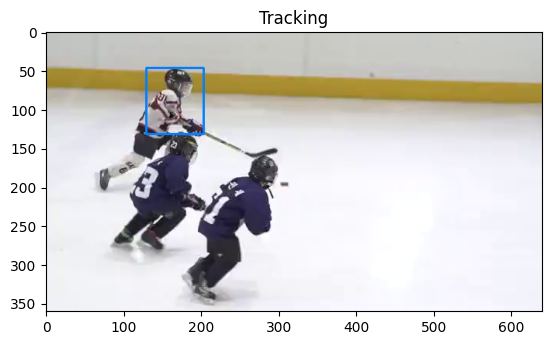

In [6]:
# Uncomment the line below to select a different bounding box
# bbox = cv2.selectROI(frame, False)

# Initialize tracker with first frame and bounding box
ok = tracker.init(frame, bbox)

# Display bounding box.
p1 = (int(bbox[0]), int(bbox[1]))
p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
cv2.rectangle(frame, p1, p2, blue, 2, 1 )

plt.imshow(frame[:,:,::-1])
plt.title("Tracking")

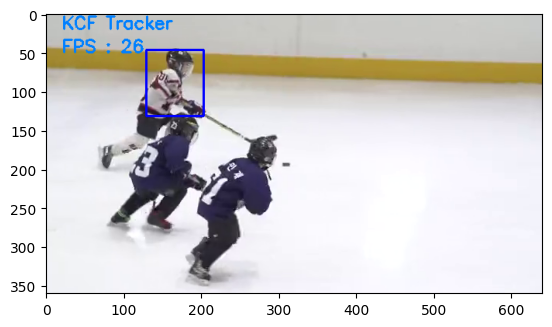

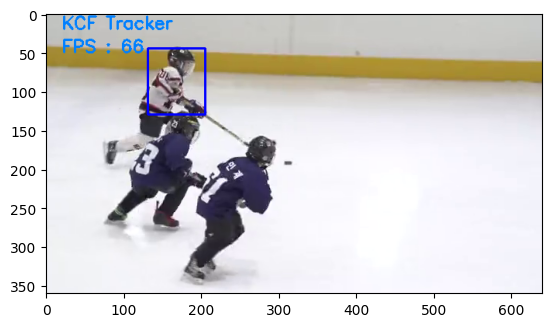

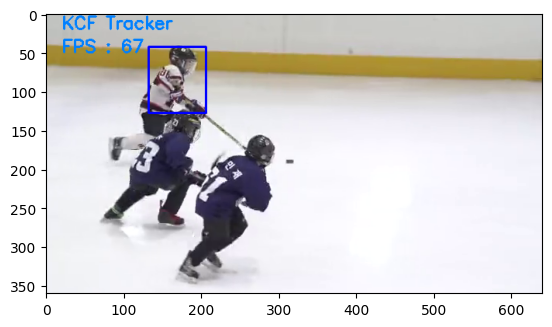

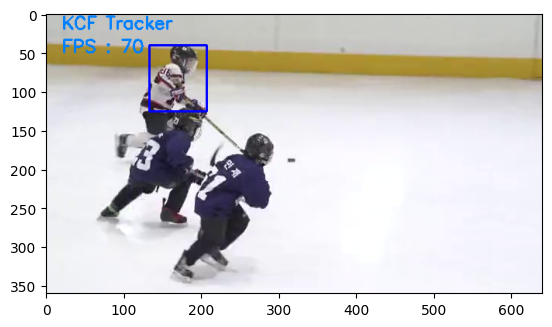

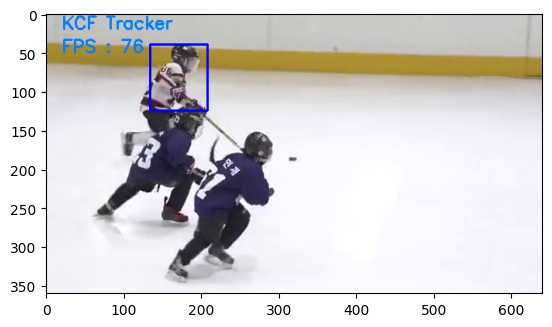

In [7]:
# We will display only first 5 frames
count = 0

while True:
    # Read a new frame
    ok, frame = video.read()
    if not ok:
        break

    # Start timer
    timer = cv2.getTickCount()
    
    # Update tracker
    ok, bbox = tracker.update(frame)
    
    # Calculate processing time and display results.
    # Calculate Frames per second (FPS)
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer);

    # Draw bounding box
    if ok:
      # Tracking success
      p1 = (int(bbox[0]), int(bbox[1]))
      p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
      cv2.rectangle(frame, p1, p2, (255,0,0), 2, 1)
    else :
      # Tracking failure
      cv2.putText(frame, "Tracking failure detected", (20,80), 
                  cv2.FONT_HERSHEY_SIMPLEX, 0.75,red,2)

    # Display tracker type on frame
    cv2.putText(frame, tracker_type + " Tracker", (20,20), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, blue,2);
    
    # Display FPS on frame
    cv2.putText(frame, "FPS : " + str(int(fps)), (20,50), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, blue, 2);

    # Display result
    plt.imshow(frame[:,:,::-1])
    plt.show()
    
    count += 1
    if count == 5:
        break

### MultiTracker

In [8]:
import cv2
from random import randint
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
trackerTypes = ['BOOSTING', 'MIL', 'KCF','TLD', 'MEDIANFLOW', 'GOTURN', 'MOSSE', 'CSRT']

In [10]:
def createTrackerByName(trackerType):
  # Create a tracker based on tracker name
  if trackerType == trackerTypes[0]:
    tracker = cv2.TrackerBoosting_create()
  elif trackerType == trackerTypes[1]:
    tracker = cv2.TrackerMIL_create()
  elif trackerType == trackerTypes[2]:
    tracker = cv2.TrackerKCF_create()
  elif trackerType == trackerTypes[3]:
    tracker = cv2.TrackerTLD_create()
  elif trackerType == trackerTypes[4]:
    tracker = cv2.TrackerMedianFlow_create()
  elif trackerType == trackerTypes[5]:
    tracker = cv2.TrackerGOTURN_create()
  elif trackerType == trackerTypes[6]:
    tracker = cv2.TrackerMOSSE_create()
  elif trackerType == trackerTypes[7]:
    tracker = cv2.TrackerCSRT_create()
  else:
    tracker = None
    print('Incorrect tracker name')
    print('Available trackers are:')
    for t in trackerTypes:
      print(t)

  return tracker

In [11]:
print("Default tracking algoritm is CSRT \n"
    "Available tracking algorithms are:\n")
for t in trackerTypes:
    print(t)

trackerType = "CSRT"

# Set video to load
videoPath = "data/videos/cycle.mp4"

Default tracking algoritm is CSRT 
Available tracking algorithms are:

BOOSTING
MIL
KCF
TLD
MEDIANFLOW
GOTURN
MOSSE
CSRT


In [12]:
# Create a video capture object to read videos
cap = cv2.VideoCapture(videoPath)

# Read first frame
success, frame = cap.read()

# quit if unable to read the video file
if not success:
    print('Failed to read video')

In [13]:
## Select boxes
colors = []
for i in range(3):
    # Select some random colors
    colors.append((randint(64, 255), randint(64, 255),
                randint(64, 255)))
# Select the bounding boxes
bboxes = [(471, 250, 66, 159), (349, 232, 69, 102)]
print('Selected bounding boxes {}'.format(bboxes))

Selected bounding boxes [(471, 250, 66, 159), (349, 232, 69, 102)]


In [16]:
# Create MultiTracker object
multiTracker = cv2.legacy.MultiTracker_create()

# Initialize MultiTracker
for bbox in bboxes:
    multiTracker.add(cv2.legacy.TrackerKCF_create(), frame, bbox)

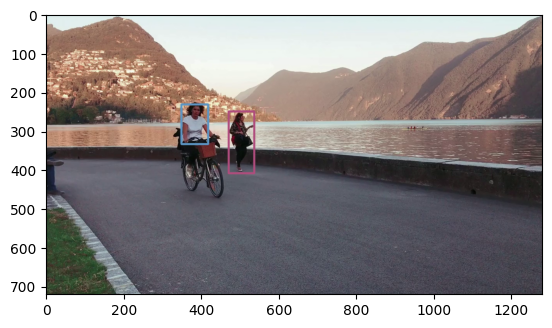

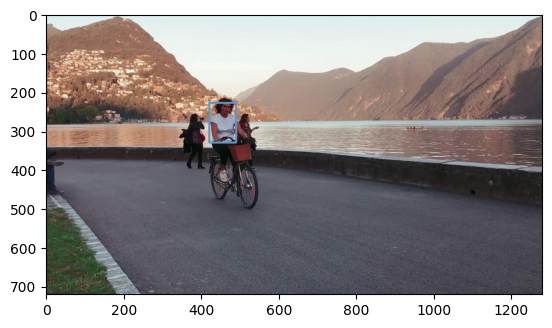

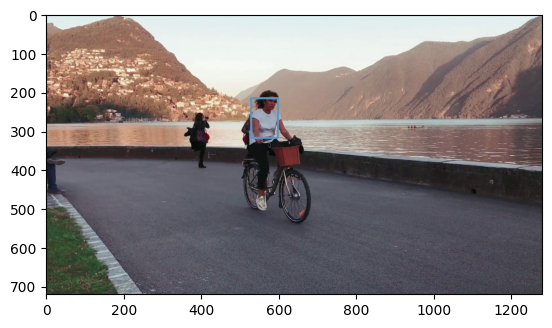

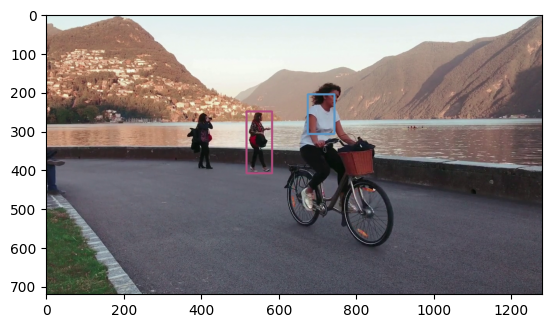

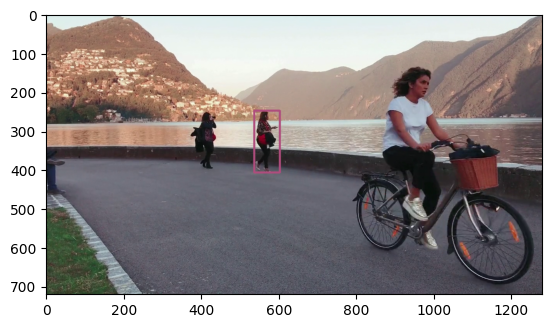

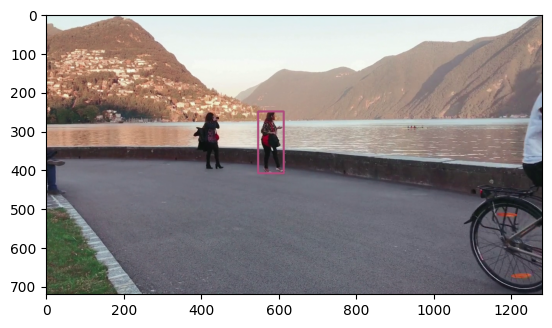

In [17]:
# We will display only 5 frames
count = 0

# Process video and track objects
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # get updated location of objects in subsequent frames
    success, boxes = multiTracker.update(frame)

    # draw tracked objects
    for i, newbox in enumerate(boxes):
        p1 = (int(newbox[0]), int(newbox[1]))
        p2 = (int(newbox[0] + newbox[2]), int(newbox[1] + newbox[3]))
        cv2.rectangle(frame, p1, p2, colors[i], 4, cv2.LINE_AA)

    # show frame
    if count % 10 == 0:
        plt.imshow(frame[:,:,::-1])
        plt.show()
    
    count += 1
    
    if count > 50:
        break